## Setup

Run this notebook from a local clone of the [svm-gmu](https://github.com/SushrutGaikwad/svm-gmu) repository. From the repo root, install the project and launch Jupyter with [uv](https://docs.astral.sh/uv/):

```bash
uv sync
uv run jupyter lab
```

The next cell puts the repo's `src/` and `experiments/` folders on the import path, so `svm_gmu` and the shared helper modules (`_common` and the `*_figs` files) import from your local clone.

In [1]:
import sys
from pathlib import Path


def _add_repo_to_path():
    """Put the repo's experiments/ and src/ folders on sys.path.

    Locates the svm-gmu repository by searching upward from the working
    directory, so the notebook runs from any local clone regardless of where
    Jupyter was started.
    """
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (base / "experiments" / "_common.py").exists():
            exp, src = base / "experiments", base / "src"
        elif (base / "_common.py").exists():
            exp, src = base, base.parent / "src"
        else:
            continue
        for path in (str(exp), str(src)):
            if path not in sys.path:
                sys.path.insert(0, path)
        return
    raise RuntimeError(
        "Could not find the svm-gmu repository. Run this notebook from a local "
        "clone (for example, `uv run jupyter lab` from the repo root)."
    )


_add_repo_to_path()

import numpy as np
import warnings
import matplotlib.pyplot as plt

import _common as C

# Render figures with the report's LaTeX serif font (pdflatex + lmodern).
C.configure_pgf()
C.GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

# High-Dimensional Scaling of Sampling vs Closed-Form SVM-GMU

This experiment asks: as the feature dimension $d$ grows, how many Monte Carlo samples per training example does a standard SVM need to match the closed-form SVM-GMU boundary?

**Setup.** For each target dimension $d$ we build a *purpose-built, genuinely $d$-dimensional* dataset (see `C.make_highdim_gmm_dataset`): two close classes in $\mathbb{R}^d$, where each of the $n=10$ examples is a genuine 3-component isotropic Gaussian mixture, $f(x) = \sum_m \tfrac{1}{3}\,\mathcal{N}(x;\, c_i + s\,u_i^{(m)},\, \sigma^2 I_d)$, whose components fill all $d$ coordinates. Because every example is a real mixture ($M=3>1$), the closed-form reference is literally SVM-GMU. (This replaces an earlier construction that lifted the 2D `close_separable` data with nuisance-noise dimensions; that version kept the signal in a 2D subspace, so it was replaced by a genuinely high-dimensional one.)

**Headline question: $N^*(d)$.** For each $d$ we sweep a ladder of sample counts $N$ (samples per example), train a standard SVM on the resulting $10N$-point cloud, and record how close its boundary gets to the closed-form SVM-GMU boundary (angle in degrees). $N^*(d)$ is the smallest $N$ at which the angle falls below a threshold $\tau$. If sampling is harder in higher dimensions, $N^*(d)$ should grow with $d$.

**Secondary view: fixed-budget angle vs $d$.** For two fixed budgets $N \in \{1000, 10000\}$ we plot the median angle as a function of $d$. If higher dimensions demand more samples, the angle should increase with $d$ for any fixed $N$.

This notebook runs the full 30-seed sweep ($d$ up to $50$, ladder to $3\times10^4$) and saves the report figures `high_dim_nstar.pgf` and `high_dim_fixed_budget.pgf`. The first run is slow; results are cached to `experiments/.cache/` so re-runs are instant. Set `FORCE_RECOMPUTE = True` to recompute.

In [2]:
# Inlined high-dimensional sweep engine (the *_figs.py scripts are gone).
# Per-example d-dimensional GMM dataset parameters (see make_highdim_gmm_dataset).
D_VALUES_FULL = [2, 3, 5, 10, 20, 50]
N_LADDER_FULL = [10, 30, 100, 300, 1000, 3000, 10000, 30000]
R_SEEDS_FULL = 30

N_PER_CLASS = 5      # examples per class -> n = 10
M_COMPONENTS = 3     # components per example (a genuine SVM-GMU mixture)
SEP = 2.0            # class-center separation along the first axis
JITTER = 0.5         # off-axis within-class jitter (boundary genuinely d-dim)
SPREAD = 0.9         # component-mean offset from the example center
SIGMA = 1.1          # per-component isotropic std

TAUS = [1.0, 2.0]            # degrees; primary curve uses tau = 2.0
FIXED_BUDGETS = [1000, 10000]
CACHE_DIR = Path(C.__file__).resolve().parent / ".cache"


def run_highdim_sweep(d_values, n_ladder, seeds):
    """Return dict with angle/offset/rms arrays of shape (len(d), len(seeds), len(ladder))."""
    nd, ns, nl = len(d_values), len(seeds), len(n_ladder)
    angle = np.full((nd, ns, nl), np.nan)
    offset = np.full((nd, ns, nl), np.nan)
    rms = np.full((nd, ns, nl), np.nan)
    for di, d in enumerate(d_values):
        for si, seed in enumerate(seeds):
            rng = np.random.default_rng(seed)
            X, y, su = C.make_highdim_gmm_dataset(
                d, rng, n_per_class=N_PER_CLASS, n_components=M_COMPONENTS,
                sep=SEP, jitter=JITTER, spread=SPREAD, sigma=SIGMA,
            )
            w_ref, b_ref = C.fit_gmu(X, y, su)
            eval_cloud = C.mc_eval_cloud(su, 2000, rng)
            for ni, n in enumerate(n_ladder):
                Xc, yc = C.build_sample_cloud(su, y, n, rng)
                w_n, b_n = C.fit_gmu(
                    Xc, yc, None, max_iter=C.svm_iter_for(len(Xc)),
                    seed=C.SVM_SEED, batch_size=256,
                )
                a, o, r = C.boundary_metrics(w_n, b_n, w_ref, b_ref, eval_cloud)
                angle[di, si, ni], offset[di, si, ni], rms[di, si, ni] = a, o, r
            print(f"d={d:>3d} seed={seed}: angle@maxN={angle[di, si, -1]:.3f}")
    return {
        "d_values": np.array(d_values), "n_ladder": np.array(n_ladder, dtype=float),
        "seeds": np.array(seeds),
        "angle": angle, "offset": offset, "rms": rms,
    }


def nstar_from_angles(res, tau):
    """N*(d) per seed: smallest ladder N with angle <= tau, else nan (cap exceeded)."""
    angle, ladder = res["angle"], res["n_ladder"]
    nd, ns, _ = angle.shape
    nstar = np.full((nd, ns), np.nan)
    for di in range(nd):
        for si in range(ns):
            below = np.where(angle[di, si, :] <= tau)[0]
            if below.size:
                nstar[di, si] = ladder[below[0]]
    return nstar


def make_nstar_figure(res):
    d_values = res["d_values"]
    cap = res["n_ladder"][-1]
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {1.0: "#dc2626", 2.0: "#2563eb"}
    for tau in TAUS:
        nstar = nstar_from_angles(res, tau)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            med = np.nanmedian(nstar, axis=1)
            lo = np.nanpercentile(nstar, 25, axis=1)
            hi = np.nanpercentile(nstar, 75, axis=1)
        ax.plot(d_values, med, marker="o", color=colors[tau], label=rf"$\tau = {tau:g}^\circ$")
        ax.fill_between(d_values, lo, hi, color=colors[tau], alpha=0.2)
        # Mark dimensions where some seeds never reached tau (cap exceeded).
        exceeded = np.isnan(nstar).any(axis=1)
        if exceeded.any():
            ax.scatter(d_values[exceeded], np.full(exceeded.sum(), cap),
                       marker="^", color=colors[tau], zorder=5)
    ax.set_yscale("log")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(r"$N^\ast(d)$: samples per example to match SVM-GMU")
    ax.set_title("Samples needed for standard SVM to match closed-form SVM-GMU")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def make_fixedbudget_figure(res):
    d_values = res["d_values"]
    ladder = [float(v) for v in res["n_ladder"]]
    fig, ax = plt.subplots(figsize=(7, 5))
    for budget in FIXED_BUDGETS:
        if float(budget) not in ladder:
            continue  # budget absent from this ladder; skip
        ni = ladder.index(float(budget))
        med = np.nanmedian(res["angle"][:, :, ni], axis=1)
        lo = np.nanpercentile(res["angle"][:, :, ni], 25, axis=1)
        hi = np.nanpercentile(res["angle"][:, :, ni], 75, axis=1)
        line, = ax.plot(d_values, med, marker="o", label=rf"$N = {budget}$")
        ax.fill_between(d_values, lo, hi, color=line.get_color(), alpha=0.2)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
               label="SVM-GMU (closed form)")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel("Angle to SVM-GMU boundary (degrees)")
    ax.set_title("Fixed sampling budget: boundary error grows with dimension")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def _cache_path(mode):
    return CACHE_DIR / f"high_dim_gmm_{mode}.npz"


def _load_or_run(mode, force, d_values, n_ladder, seeds):
    path = _cache_path(mode)
    if path.exists() and not force:
        data = np.load(path, allow_pickle=False)
        print(f"loaded cache {path.name}")
        return {k: data[k] for k in data.files}
    res = run_highdim_sweep(d_values, n_ladder, seeds)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(path, **res)
    print(f"wrote cache {path.name}")
    return res

loaded cache high_dim_gmm_full.npz


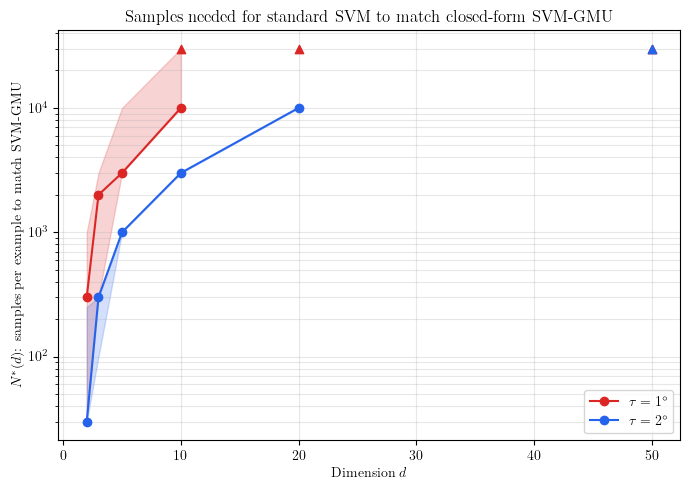

In [3]:
# Full 30-seed sweep (cached). First run is slow; re-runs load the cache.
FORCE_RECOMPUTE = False
seeds = C.make_seeds(C.MASTER_SEED, R_SEEDS_FULL)
res = _load_or_run("full", FORCE_RECOMPUTE, D_VALUES_FULL, N_LADDER_FULL, seeds)

# N*(d): samples-to-match vs dimension (saved as high_dim_nstar.pgf).
fig = make_nstar_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_nstar.pgf", backend="pgf", bbox_inches="tight")
plt.show()

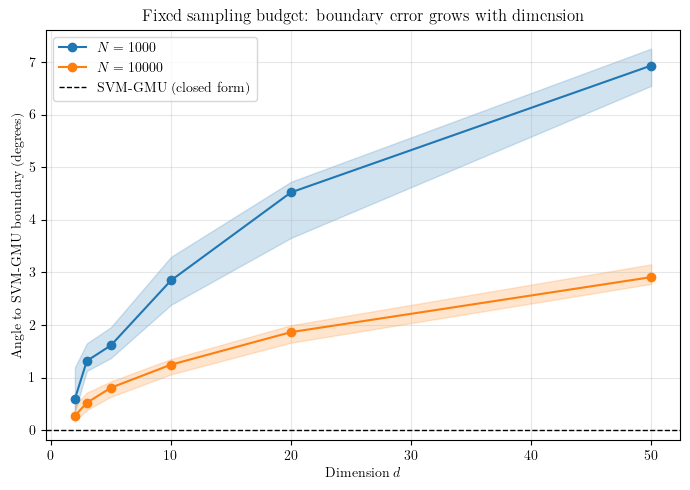

In [4]:
# Fixed-budget angle vs dimension (saved as high_dim_fixed_budget.pgf).
fig = make_fixedbudget_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_fixed_budget.pgf", backend="pgf", bbox_inches="tight")
plt.show()